In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [26]:
# Hyper parameters
batch_size = 100
learning_rate = 0.001
epochs = 5

In [5]:
# Load data
transform = transforms.ToTensor()

train_ds = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_ds = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False
)

In [18]:
# shape of batch of data
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([100, 1, 28, 28])
torch.Size([100])


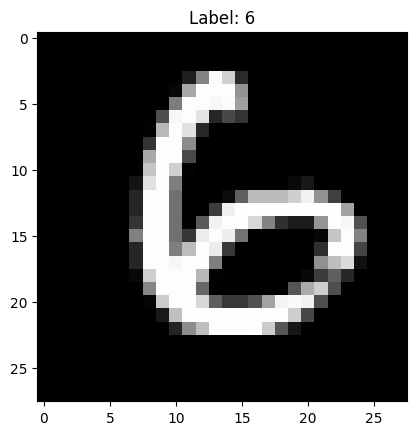

In [17]:
# visualize image
for images, labels in train_loader:
    for img, label in zip(images, labels):
        plt.imshow(img.squeeze(), cmap="grey")
        plt.title(f"Label: {label}")
        break
    break

In [25]:
# Create neural network
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.network(x)

model = MNISTModel().to(device)
print(model)

MNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [24]:
for param in model.parameters():
    print(param.shape)

torch.Size([32, 784])
torch.Size([32])
torch.Size([10, 32])
torch.Size([10])


In [27]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [30]:
# training loop
for epoch in range(epochs):
    model.train() # set training mode
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        outputs = model(images)
        # Loss 
        loss = criterion(outputs, labels)
        # Backward
        optimizer.zero_grad()
        loss.backward()
        # updation
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

print("Training completed")

Epoch [1/5] Loss: 0.3930
Epoch [2/5] Loss: 0.1610
Epoch [3/5] Loss: 0.1101
Epoch [4/5] Loss: 0.0834
Epoch [5/5] Loss: 0.0654
Training completed


In [33]:
# Model testing
model.eval()

correct =0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()

accuracy = 100* correct/ total

print(f"Train accuracy: {accuracy:.2f}%")

Train accuracy: 97.30%


In [34]:
# Save the model
torch.save(model.state_dict(),"mnist_model.pth")
print("Saved succesfully")

Saved succesfully
